## Import Libraries and Create Data Cleaner

In [35]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import json
import os
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


## Set Data Path and Get Class Names

In [36]:
data_path = "D:/Soil Type identification/Train"

# Get class names
class_names = sorted([d for d in os.listdir(data_path) 
                      if os.path.isdir(os.path.join(data_path, d))])
print(f"Classes: {class_names}")
print(f"Number of classes: {len(class_names)}")

Classes: ['Alluvial_Soil', 'Arid_Soil', 'Black_Soil', 'Laterite_Soil', 'Mountain_Soil', 'Red_Soil', 'Yellow_Soil']
Number of classes: 7


##  Scan and Collect Valid Images

In [37]:
# Collect all valid image paths and labels
image_paths = []
labels = []
valid_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp', '.jfif', '.webp'}

print("\nScanning directories...")
for class_idx, class_name in enumerate(class_names):
    class_path = os.path.join(data_path, class_name)
    count = 0
    for file in os.listdir(class_path):
        ext = os.path.splitext(file)[1].lower()
        if ext in valid_extensions:
            file_path = os.path.join(class_path, file)
            # Verify with OpenCV
            img = cv2.imread(file_path)
            if img is not None:
                image_paths.append(file_path)
                labels.append(class_idx)
                count += 1
            else:
                print(f"  Skipping invalid: {file}")
    print(f"  {class_name}: {count} images")

print(f"\n✅ Total valid images: {len(image_paths)}")


Scanning directories...
  Alluvial_Soil: 694 images
  Arid_Soil: 284 images
  Black_Soil: 1173 images
  Laterite_Soil: 219 images
  Mountain_Soil: 201 images
  Red_Soil: 1126 images
  Yellow_Soil: 1401 images

✅ Total valid images: 5098


##  Shuffle and Split Data

In [38]:
# Shuffle
indices = np.random.permutation(len(image_paths))
image_paths = np.array(image_paths)[indices]
labels = np.array(labels)[indices]

# Split
split_idx = int(len(image_paths) * 0.8)
train_paths = image_paths[:split_idx]
train_labels = labels[:split_idx]
val_paths = image_paths[split_idx:]
val_labels = labels[split_idx:]

print(f"\nTraining samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")


Training samples: 4078
Validation samples: 1020


##   Define Data Loading Functions

In [39]:
def load_image_cv(path, label):
    """Load and preprocess image using OpenCV"""
    img = cv2.imread(path.numpy().decode('utf-8'))
    if img is None:
        # Return black image if loading fails
        img = np.zeros((128, 128, 3), dtype=np.uint8)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (128, 128))
    img = img.astype(np.float32) / 255.0
    return img, label

def tf_load_image(path, label):
    """TensorFlow wrapper for OpenCV loading"""
    img, lbl = tf.py_function(
        load_image_cv, 
        [path, label], 
        [tf.float32, tf.int32]
    )
    img.set_shape([128, 128, 3])
    lbl.set_shape([])
    # Convert label to one-hot
    lbl_one_hot = tf.one_hot(lbl, len(class_names))
    return img, lbl_one_hot

## Create TensorFlow Datasets

In [40]:
# Create datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_dataset = train_dataset.map(tf_load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_dataset = val_dataset.map(tf_load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

print("✅ Datasets created successfully!")

✅ Datasets created successfully!


## Build Model

In [43]:
model = Sequential([
    Input(shape=(128, 128, 3)),
    
    Conv2D(32, 3, padding='same', activation='relu'),
    Conv2D(32, 3, activation='relu'),
    MaxPool2D(2, 2),
    
    Conv2D(64, 3, padding='same', activation='relu'),
    Conv2D(64, 3, activation='relu'),
    MaxPool2D(2, 2),
    
    Conv2D(128, 3, padding='same', activation='relu'),
    Conv2D(128, 3, activation='relu'),
    MaxPool2D(2, 2),
    
    Conv2D(256, 3, padding='same', activation='relu'),
    Conv2D(256, 3, activation='relu'),
    MaxPool2D(2, 2),
    
    Flatten(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(len(class_names), activation='softmax')
])

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_38 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 conv2d_39 (Conv2D)          (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d_19 (MaxPoolin  (None, 63, 63, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_40 (Conv2D)          (None, 63, 63, 64)        18496     
                                                                 
 conv2d_41 (Conv2D)          (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_20 (MaxPoolin  (None, 30, 30, 64)       0         
 g2D)                                                 

##  Compile Model

In [44]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled!")

✅ Model compiled!


##  Train Model

In [45]:
print("\n" + "="*60)
print("Starting Training...")
print("="*60)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    verbose=1
)

print("\n✅ Training completed!")


Starting Training...
Epoch 1/20
128/128 [==============================] - 18s 135ms/step - loss: 1.0472 - accuracy: 0.5932 - val_loss: 0.7585 - val_accuracy: 0.7824
Epoch 2/20
128/128 [==============================] - 16s 125ms/step - loss: 0.5397 - accuracy: 0.8195 - val_loss: 0.3844 - val_accuracy: 0.8549
Epoch 3/20
128/128 [==============================] - 16s 127ms/step - loss: 0.4216 - accuracy: 0.8580 - val_loss: 0.3273 - val_accuracy: 0.8804
Epoch 4/20
128/128 [==============================] - 16s 128ms/step - loss: 0.4261 - accuracy: 0.8602 - val_loss: 0.3130 - val_accuracy: 0.8824
Epoch 5/20
128/128 [==============================] - 16s 128ms/step - loss: 0.3643 - accuracy: 0.8725 - val_loss: 0.3557 - val_accuracy: 0.8686
Epoch 6/20
128/128 [==============================] - 16s 128ms/step - loss: 0.3379 - accuracy: 0.8862 - val_loss: 0.2865 - val_accuracy: 0.8961
Epoch 7/20
128/128 [==============================] - 17s 130ms/step - loss: 0.3126 - accuracy: 0.8948 - val

## Save Model and History

In [46]:
# Save model
model.save("trained_soil_model.keras")
print("✅ Model saved as 'trained_soil_model.keras'")

# Save training history
with open("training_hist_soil.json", "w") as f:
    json.dump(history.history, f)
print("✅ Training history saved")

# Print final metrics
print(f"\n📊 Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"📊 Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

✅ Model saved as 'trained_soil_model.keras'
✅ Training history saved

📊 Final Training Accuracy: 0.9296
📊 Final Validation Accuracy: 0.9078


## Plot Training Results

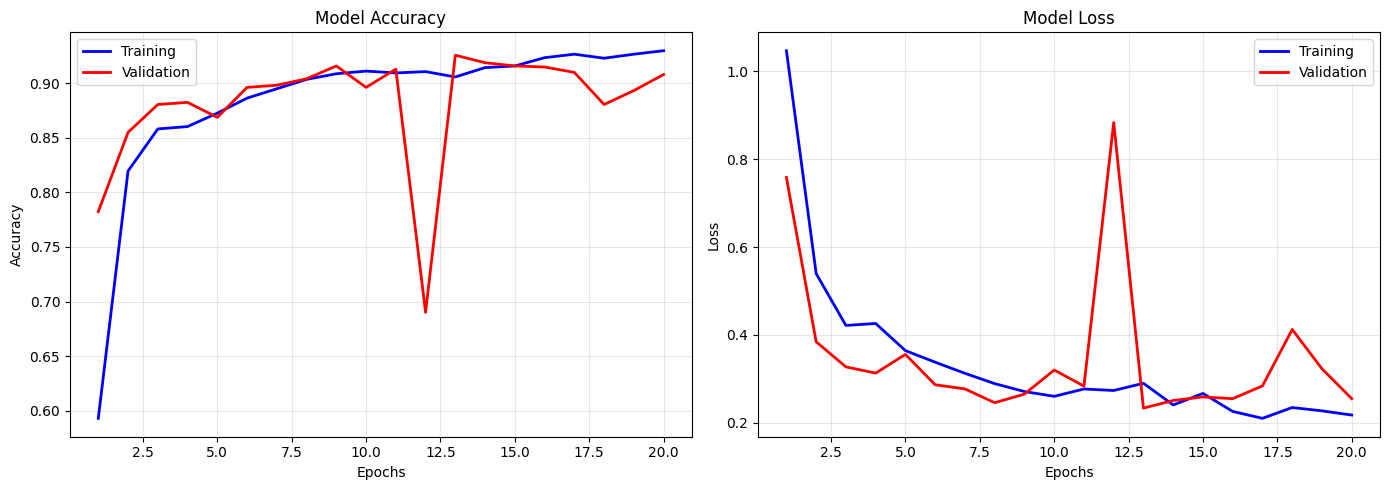

In [47]:
epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], 'b-', linewidth=2, label='Training')
plt.plot(epochs, history.history['val_accuracy'], 'r-', linewidth=2, label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], 'b-', linewidth=2, label='Training')
plt.plot(epochs, history.history['val_loss'], 'r-', linewidth=2, label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results.png')
plt.show()

##  Test with a Single Image

Testing image: D:/Soil Type identification/Train/Alluvial_Soil/1 - Copy.jpg

✅ Predicted: Alluvial Soil
✅ Confidence: 64.51%

📊 All Predictions:
---------------------------------------------
Alluvial Soil       : ████████████░░░░░░░░ 64.51%
Arid Soil           : ██░░░░░░░░░░░░░░░░░░ 13.04%
Black Soil          : ░░░░░░░░░░░░░░░░░░░░  0.03%
Laterite Soil       : ███░░░░░░░░░░░░░░░░░ 19.74%
Mountain Soil       : ░░░░░░░░░░░░░░░░░░░░  0.90%
Red Soil            : ░░░░░░░░░░░░░░░░░░░░  0.06%
Yellow Soil         : ░░░░░░░░░░░░░░░░░░░░  1.71%


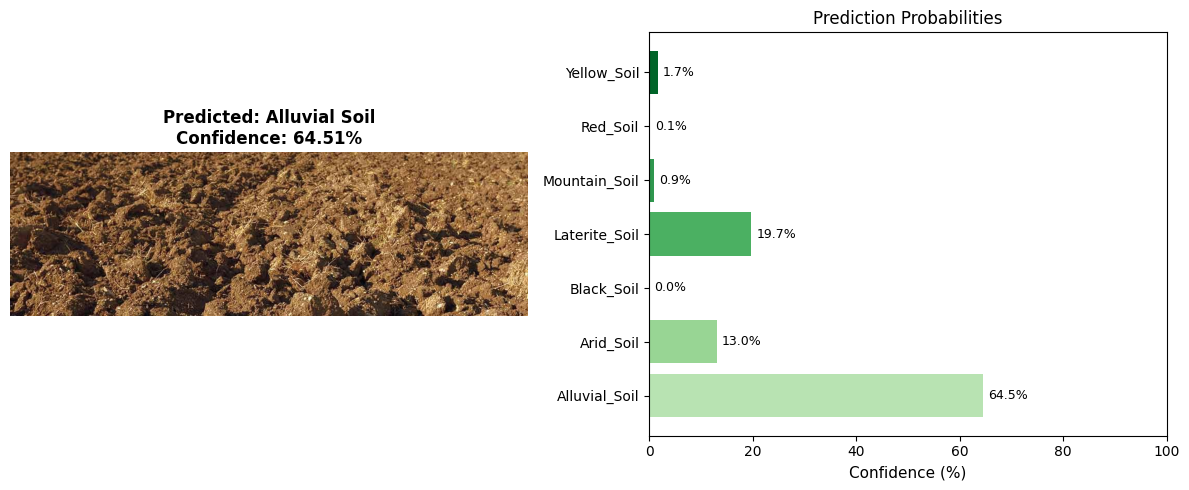

In [48]:
def predict_soil(image_path):
    """Predict soil type from a single image"""
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Cannot load: {image_path}")
        return
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))
    img_array = np.array([img_resized]) / 255.0
    
    pred = model.predict(img_array, verbose=0)
    idx = np.argmax(pred[0])
    conf = pred[0][idx] * 100
    
    print(f"\n✅ Predicted: {class_names[idx].replace('_', ' ')}")
    print(f"✅ Confidence: {conf:.2f}%")
    
    # Display all probabilities
    print("\n📊 All Predictions:")
    print("-" * 45)
    for i, name in enumerate(class_names):
        prob = pred[0][i] * 100
        bar = '█' * int(prob / 5) + '░' * (20 - int(prob / 5))
        print(f"{name.replace('_', ' '):20s}: {bar} {prob:5.2f}%")
    
    # Plot
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title(f"Predicted: {class_names[idx].replace('_', ' ')}\nConfidence: {conf:.2f}%", 
             fontsize=12, fontweight='bold')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(class_names)))
    bars = plt.barh(class_names, pred[0] * 100, color=colors)
    plt.xlabel('Confidence (%)', fontsize=11)
    plt.title('Prediction Probabilities', fontsize=12)
    plt.xlim(0, 100)
    
    # Add value labels
    for bar, prob in zip(bars, pred[0] * 100):
        plt.text(prob + 1, bar.get_y() + bar.get_height()/2, f'{prob:.1f}%', 
                va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Test with your image
test_image = "D:/Soil Type identification/Train/Alluvial_Soil/1 - Copy.jpg"
print(f"Testing image: {test_image}")
print("="*50)
predict_soil(test_image)

## Evaluate on Validation Set 

Evaluating on validation set...

CLASSIFICATION REPORT
               precision    recall  f1-score   support

Alluvial_Soil     0.7189    0.9779    0.8287       136
    Arid_Soil     0.5000    0.2131    0.2989        61
   Black_Soil     0.9958    0.9833    0.9895       240
Laterite_Soil     0.7391    0.4722    0.5763        36
Mountain_Soil     0.6818    0.7317    0.7059        41
     Red_Soil     0.9771    1.0000    0.9884       213
  Yellow_Soil     0.9895    0.9693    0.9793       293

     accuracy                         0.9078      1020
    macro avg     0.8003    0.7639    0.7667      1020
 weighted avg     0.9018    0.9078    0.8976      1020



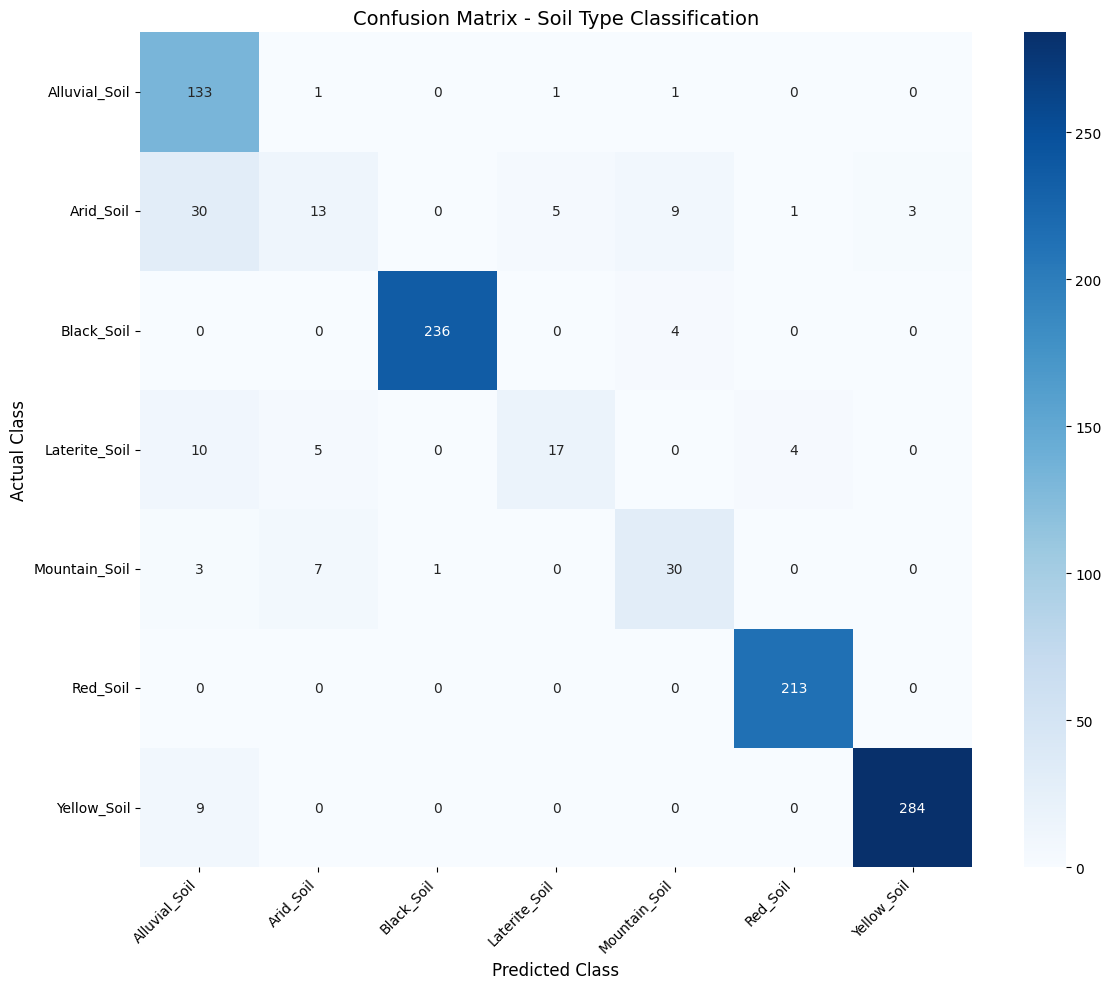


PER-CLASS ACCURACY
Alluvial_Soil            : 97.79% (133/136)
Arid_Soil                : 21.31% (13/61)
Black_Soil               : 98.33% (236/240)
Laterite_Soil            : 47.22% (17/36)
Mountain_Soil            : 73.17% (30/41)
Red_Soil                 : 100.00% (213/213)
Yellow_Soil              : 96.93% (284/293)


In [49]:
print("Evaluating on validation set...")
print("="*60)

# Get predictions for validation set
y_pred_list = []
y_true_list = []

for images, labels in val_dataset:
    predictions = model.predict(images, verbose=0)
    y_pred_list.extend(np.argmax(predictions, axis=1))
    y_true_list.extend(np.argmax(labels.numpy(), axis=1))

y_pred = np.array(y_pred_list)
y_true = np.array(y_true_list)

# Classification Report
print("\nCLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 10})
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Actual Class', fontsize=12)
plt.title('Confusion Matrix - Soil Type Classification', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\n" + "="*60)
print("PER-CLASS ACCURACY")
print("="*60)
for i, class_name in enumerate(class_names):
    correct = cm[i, i]
    total = np.sum(cm[i, :])
    accuracy = correct / total * 100 if total > 0 else 0
    print(f"{class_name:25s}: {accuracy:5.2f}% ({correct}/{total})")